# BANK CUSTOMER SEGMENTATION

### Prepare the data

In [9]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Import data
df = pd.read_csv('Bank_Churn.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Create a DataFrame containing all fields except "CustomerId", "Surname" and "Exited"
subset = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
subset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [3]:
#--- Make text fields numeric ----
# Make a copy of data
df_clean = subset.copy()

# Convert 'Gender' column to binary numeric values: Female = 1, Male = 0 
df_clean.Gender = np.where(df_clean.Gender == 'Female', 1, 0)

# Perform One-Hot Encoding on the 'Geography' column to create dummy variables
df_clean = pd.get_dummies(df_clean, columns=['Geography'], dtype='int', prefix='', prefix_sep='')
df_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1


In [4]:
# Explore the data
df_clean.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.454300,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.501400,0.250900,0.247700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.500023,0.433553,0.431698
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000
50%,652.000000,0.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000


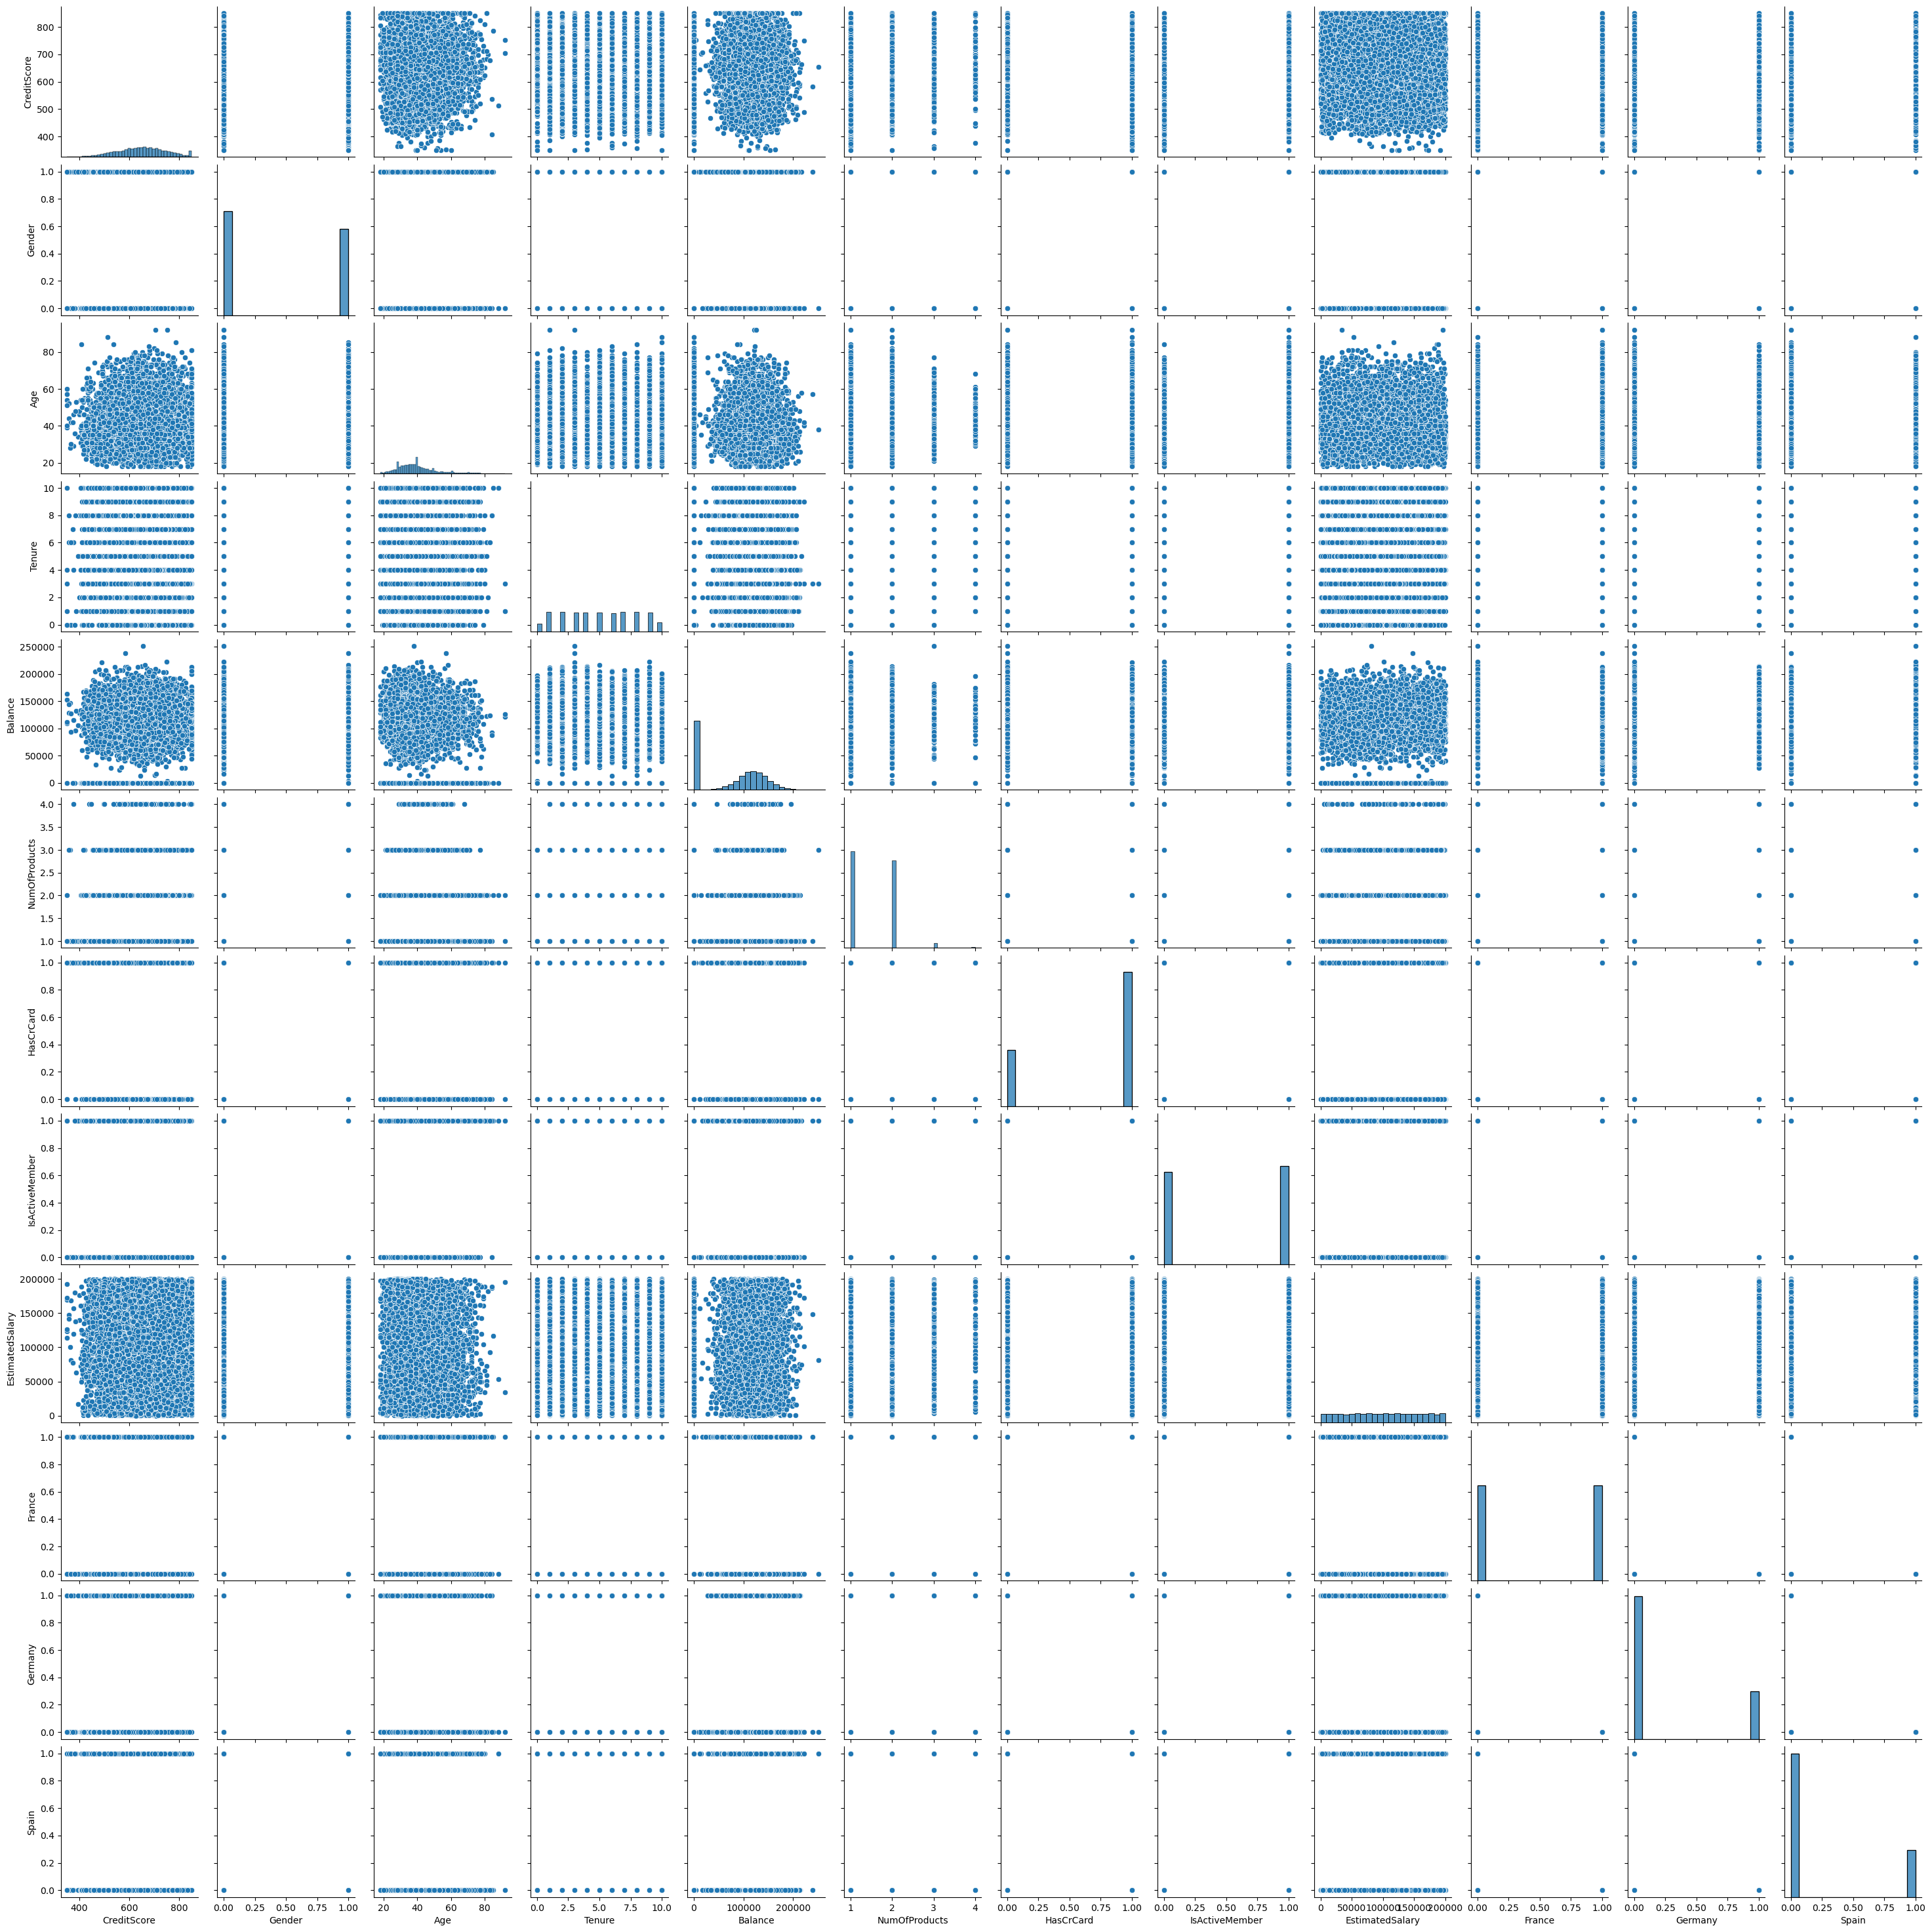

In [6]:
sns.pairplot(df_clean)

In [8]:
# Create ProductsPerYear column
df_clean['ProductsPerYear'] = np.where(df_clean.Tenure == 0, df_clean.NumOfProducts, df_clean.NumOfProducts	/ df_clean.Tenure)
df_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500


### Cluster the data

In [10]:
# Standardize the data ~ N(0,1)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)
df_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,-0.326221,1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,-0.016781
1,-0.440036,1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,0.967674
2,-1.536794,1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,-0.262894
3,0.501521,1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0.997204,-0.578736,-0.573809,2.936584
4,2.063884,1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-1.002804,-0.578736,1.742740,-0.016781


In [11]:
df_scaled.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-4.824585e-16,-2.131628e-18,2.318146e-16,-1.078249e-16,-6.252776e-17,1.634248e-17,-5.258016e-17,-7.389644e-17,-2.877698e-17,2.096101e-17,-7.069900e-17,-4.689582e-17,1.957545e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-3.109504e+00,-9.124191e-01,-1.994969e+00,-1.733315e+00,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-1.740268e+00,-1.002804e+00,-5.787359e-01,-5.738092e-01,-8.043445e-01
25%,-6.883586e-01,-9.124191e-01,-6.600185e-01,-6.959818e-01,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-8.535935e-01,-1.002804e+00,-5.787359e-01,-5.738092e-01,-6.074535e-01
50%,1.522218e-02,-9.124191e-01,-1.832505e-01,-4.425957e-03,3.319639e-01,-9.115835e-01,6.460917e-01,9.702426e-01,1.802807e-03,9.972039e-01,-5.787359e-01,-5.738092e-01,-3.449322e-01
75%,6.981094e-01,1.095988e+00,4.842246e-01,6.871299e-01,8.199205e-01,8.077366e-01,6.460917e-01,9.702426e-01,8.572431e-01,9.972039e-01,1.727904e+00,-5.738092e-01,3.113709e-01
max,2.063884e+00,1.095988e+00,5.061197e+00,1.724464e+00,2.795323e+00,4.246377e+00,6.460917e-01,9.702426e-01,1.737200e+00,9.972039e-01,1.727904e+00,1.742740e+00,6.874403e+00


In [13]:
# Fit Kmeans model on the standardized data with 2 to 15 clusters 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_, metric='euclidean', sample_size=None))

Text(0.5, 1.0, 'Number of Clusters vs. Inertia')

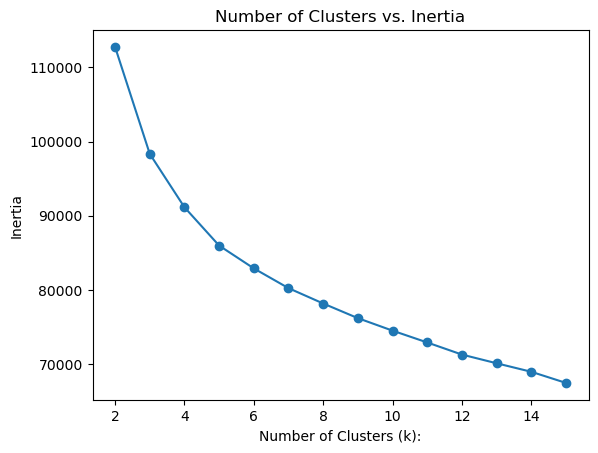

In [14]:
# Plot the inertia values
inertia_series = pd.Series(inertia_values, index=range(2,16)) # turn list to series

inertia_series.plot(marker='o')
plt.xlabel('Number of Clusters (k):')
plt.ylabel('Inertia')
plt.title('Number of Clusters vs. Inertia')

The elbow of the graph is at k = 5, so I'll fit a K-Means model using that value of k.

In [15]:
kmeans5 = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans5.fit(df_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [16]:
# Check the number of customers in each cluster
from collections import Counter
Counter(kmeans5.labels_)

Counter({np.int32(3): 2343,
         np.int32(2): 2336,
         np.int32(4): 2329,
         np.int32(1): 2305,
         np.int32(0): 687})

<Axes: >

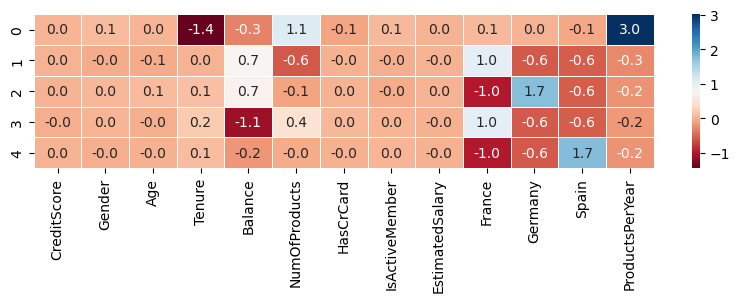

In [18]:
# Create a heatmap of cluster centers
cluster_kmeans5 = pd.DataFrame(kmeans5.cluster_centers_, columns=df_scaled.columns)

plt.figure(figsize=(10,2))
sns.heatmap(cluster_kmeans5, annot=True, cmap='RdBu', fmt='.1f', linewidths=.5)

* 0: Many product in short time
* 1: French customers with few products, high balance
* 2: German customers with high balance
* 3: French customers with more products, low balance
* 4: Spanish customers

### Cluster the data without geography
Take a look at the summary stats by country, and exclude the countries fields.

In [19]:
df_geo = subset.copy()
df_geo.Gender = np.where(df_geo.Gender == 'Female', 1, 0)
df_geo.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,1,42,2,0.00,1,1,1,101348.88
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58
2,502,France,1,42,8,159660.80,3,1,0,113931.57
3,699,France,1,39,1,0.00,2,0,0,93826.63
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10


In [20]:
df_geo.groupby('Geography').mean()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Geography,,,,,,,,,
France,649.668329,0.450937,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814
Germany,651.453567,0.475488,39.771622,5.009964,119730.116134,1.519729,0.713830,0.497409,101113.435102
Spain,651.333872,0.439645,38.890997,5.032297,61818.147763,1.539362,0.694792,0.529673,99440.572281


In [21]:
df_geo[df_geo.Geography == 'France'].Balance.round(-5).value_counts()

Balance
0.0         2459
100000.0    2123
200000.0     432
Name: count, dtype: int64

In [22]:
df_geo[df_geo.Geography == 'Germany'].Balance.round(-5).value_counts()

Balance
100000.0    2176
200000.0     314
0.0           19
Name: count, dtype: int64

In [23]:
df_geo[df_geo.Geography == 'Spain'].Balance.round(-5).value_counts()

Balance
0.0         1214
100000.0    1040
200000.0     222
300000.0       1
Name: count, dtype: int64

In [24]:
df_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,-0.326221,1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,-0.016781
1,-0.440036,1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,0.967674
2,-1.536794,1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,-0.262894
3,0.501521,1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0.997204,-0.578736,-0.573809,2.936584
4,2.063884,1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-1.002804,-0.578736,1.742740,-0.016781


In [25]:
df_scaled_no_geo = df_scaled.drop(columns=['France', 'Germany', 'Spain'])
df_scaled_no_geo.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ProductsPerYear
0,-0.326221,1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.016781
1,-0.440036,1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0.967674
2,-1.536794,1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.262894
3,0.501521,1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,2.936584
4,2.063884,1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.016781


In [26]:
# Fit Kmeans model on the standardized data with 2 to 15 clusters 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_scaled_no_geo)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled_no_geo, kmeans.labels_, metric='euclidean', sample_size=None))

Text(0.5, 1.0, 'Number of Clusters vs. Inertia')

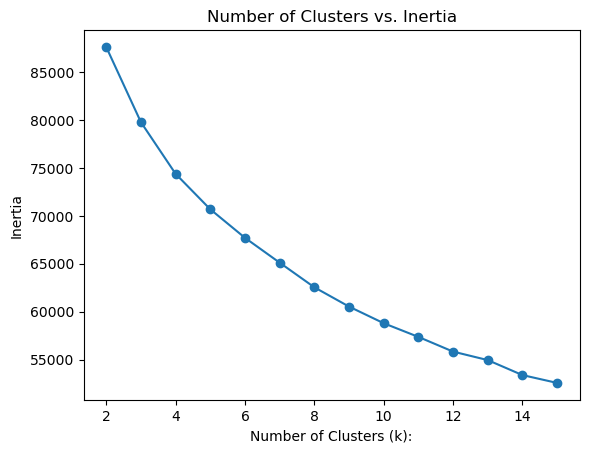

In [27]:
# Plot the inertia values
inertia_series = pd.Series(inertia_values, index=range(2,16)) # turn list to series

inertia_series.plot(marker='o')
plt.xlabel('Number of Clusters (k):')
plt.ylabel('Inertia')
plt.title('Number of Clusters vs. Inertia')

Now the elbow is 4, so I'll fit a K-Means model using a k value of 4.

In [28]:
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans4.fit(df_scaled_no_geo)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [29]:
# Check the number of customers in each cluster
Counter(kmeans4.labels_)

Counter({np.int32(1): 3223,
         np.int32(2): 2366,
         np.int32(0): 2276,
         np.int32(3): 2135})

<Axes: >

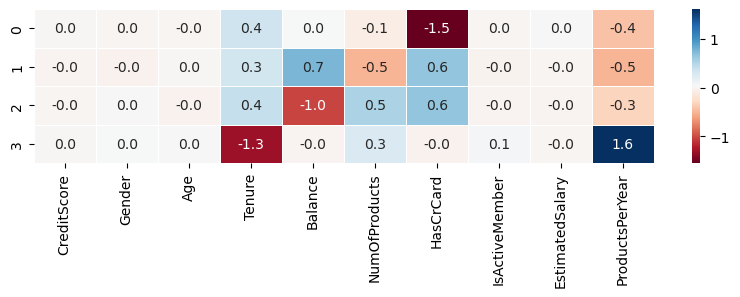

In [30]:
# Create a heatmap of cluster centers
cluster_kmeans4 = pd.DataFrame(kmeans4.cluster_centers_, columns=df_scaled_no_geo.columns)

plt.figure(figsize=(10,2))
sns.heatmap(cluster_kmeans4, annot=True, cmap='RdBu', fmt='.1f', linewidths=.5)

* 0: Don't have a credit card
* 1: High balance, few products and have a credit card
* 2: Low balance, more products and have a credit card
* 3: Many products in a short amount of time

### Explore and make recommendations

In [32]:
# Merge data
df_final = pd.concat([df_clean, df.Exited, pd.Series(kmeans4.labels_, name='Cluster')], axis=1)
df_final.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear,Exited,Cluster
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500,1,2
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000,0,3
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375,1,2
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000,0,3
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500,0,1


In [35]:
# View the churn rate (% of customers who Exited) for each cluster
df_final.groupby('Cluster')['Exited'].mean()

Cluster
0    0.209578
1    0.226807
2    0.164835
3    0.205621
Name: Exited, dtype: float64

### Make recommendations 
Make recommendations for how to cater to each customer segment

* 0: Don't have a credit card
* 1: High balance, few products and have a credit card
* 2: Low balance, more products and have a credit card
* 3: Many products in a short amount of time

**Recommend**
* 0: Create an entry level credit card
* 1: Attract high balance customers to stay
* 2: Reward them for their high tenure, French and Spanish customers
* 3: Encourage them to stay